In [1]:
import sys
sys.path.insert(0, '..')

import json
import pandas as pd
import matplotlib.pyplot as plt
from src.evaluation.retrieval_metrics import load_eval_questions

questions = load_eval_questions('../data/processed/eval_questions.csv')
print(f'Loaded {len(questions)} questions')

Loaded 30 questions


In [2]:
with open('../data/processed/eval_report.json') as f:
    report = json.load(f)

print('Generated:', report['timestamp'])

Generated: 2026-06-04T20:51:54Z


In [3]:
dense = report['retrieval_dense']['overall']

rows = []
for k in [1, 3, 5]:
    rows.append({
        'K':         k,
        'Recall@K':  dense.get(f'recall@{k}', 0),
        'Precision@K': dense.get(f'precision@{k}', 0),
        'Hit@K':     dense.get(f'hit@{k}', 0),
    })

df = pd.DataFrame(rows).set_index('K')
print('Dense retrieval metrics:')
print(df.round(3))
print(f"\nMRR: {dense.get('mrr', 0):.3f}")
print(f"Avg latency: {dense.get('avg_latency_ms', 0):.0f} ms")

Dense retrieval metrics:
   Recall@K  Precision@K  Hit@K
K                              
1     0.332        0.560   0.56
3     0.468        0.520   0.72
5     0.524        0.464   0.76

MRR: 0.643
Avg latency: 0 ms


In [4]:
by_diff = report['retrieval_dense'].get('by_difficulty', {})

rows = []
for diff in ['easy', 'medium', 'hard']:
    if diff in by_diff:
        m = by_diff[diff]
        rows.append({
            'Difficulty': diff,
            'n':          m.get('n', 0),
            'Recall@5':   m.get('recall@5', 0),
            'MRR':        m.get('mrr', 0),
            'Hit@1':      m.get('hit@1', 0),
        })

pd.DataFrame(rows).set_index('Difficulty').round(3)

,n,Recall@5,MRR,Hit@1
Difficulty,,,,
easy,10,0.70,0.600,0.5
medium,10,0.44,0.683,0.6
hard,5,0.34,0.650,0.6


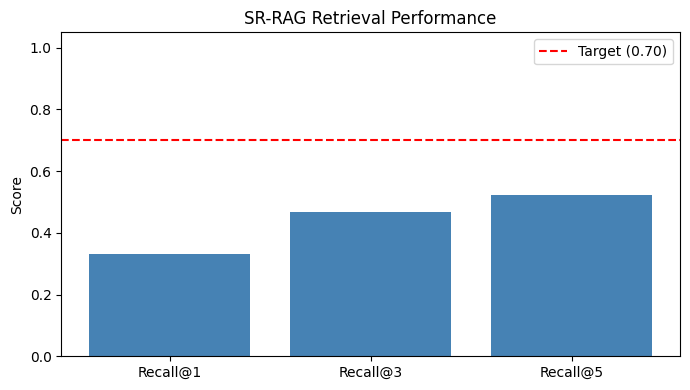

Recall@5: 0.524 (target: 0.70)


In [5]:
ks = [1, 3, 5]
recalls = [dense.get(f'recall@{k}', 0) for k in ks]

plt.figure(figsize=(7, 4))
plt.bar([f'Recall@{k}' for k in ks], recalls, color='steelblue')
plt.axhline(0.7, color='red', linestyle='--', label='Target (0.70)')
plt.ylabel('Score')
plt.title('SR-RAG Retrieval Performance')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig('../docs/figures/eval_retrieval_metrics.png', dpi=150)
plt.show()
print(f"Recall@5: {dense.get('recall@5', 0):.3f} (target: 0.70)")

In [6]:
if 'answer_quality' in report:
    aq = report['answer_quality']['overall']
    print('Answer quality (mock LLM):')
    for key in ['composite_score', 'keyword_coverage', 'citation_coverage',
                'source_grounding', 'length_ok_rate']:
        print(f"  {key:<22}: {aq.get(key, 0):.3f}")
    if 'refusal_accuracy' in aq:
        print(f"  {'refusal_accuracy':<22}: {aq.get('refusal_accuracy', 0):.3f}")
    print(f"\nNote: answer metrics will be more meaningful after plugging in a real LLM.")

Answer quality (mock LLM):
  composite_score       : 0.435
  keyword_coverage      : 0.190
  citation_coverage     : 0.412
  source_grounding      : 0.500
  length_ok_rate        : 1.000
  refusal_accuracy      : 0.000

Note: answer metrics will be more meaningful after plugging in a real LLM.


In [7]:
from pathlib import Path

dense = report['retrieval_dense']['overall']
aq = report.get('answer_quality', {}).get('overall', {})

summary = f"""## Evaluation Results

### Retrieval (dense, {len([q for q in questions if q['difficulty'] != 'unanswerable'])} answerable questions)

| Metric | Score |
|--------|-------|
| Recall@1 | {dense.get('recall@1', 0):.3f} |
| Recall@3 | {dense.get('recall@3', 0):.3f} |
| Recall@5 | {dense.get('recall@5', 0):.3f} |
| MRR | {dense.get('mrr', 0):.3f} |
| Hit@1 | {dense.get('hit@1', 0):.3f} |
| Avg latency | {dense.get('avg_latency_ms', 0):.0f} ms |

### Answer Quality (mock LLM)

| Metric | Score |
|--------|-------|
| Composite | {aq.get('composite_score', 'N/A')} |
| Keyword coverage | {aq.get('keyword_coverage', 'N/A')} |
| Refusal accuracy | {aq.get('refusal_accuracy', 'N/A')} |
"""

Path('../docs/writeups/eval_results.md').write_text(summary)
print(summary)
print("Saved to docs/writeups/eval_results.md")

## Evaluation Results

### Retrieval (dense, 25 answerable questions)

| Metric | Score |
|--------|-------|
| Recall@1 | 0.332 |
| Recall@3 | 0.468 |
| Recall@5 | 0.524 |
| MRR | 0.643 |
| Hit@1 | 0.560 |
| Avg latency | 0 ms |

### Answer Quality (mock LLM)

| Metric | Score |
|--------|-------|
| Composite | 0.435 |
| Keyword coverage | 0.19 |
| Refusal accuracy | 0.0 |

Saved to docs/writeups/eval_results.md
